# Supervised Learning | Polynomial Regression (Manufacturing)

### Importing Libraries 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Importing Dataset & Extracting Featuers

In [3]:
manufacturing = pd.read_csv('manufacturing.csv')
manufacturing

,Number of Units,Manufacturing Cost
0,1.000000,95.066056
1,1.185994,96.531750
2,1.191499,73.661311
3,1.204771,95.566843
4,1.298773,98.777013
...,...,...
995,8.099710,23.855067
996,8.739752,27.536542
997,8.780888,25.973787
998,8.897700,25.138311


In [4]:
manufacturing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Number of Units     1000 non-null   float64
 1   Manufacturing Cost  1000 non-null   float64
dtypes: float64(2)
memory usage: 15.8 KB


In [6]:
manufacturing.describe().round(2)

,Number of Units,Manufacturing Cost
count,1000.00,1000.00
mean,4.47,40.05
std,1.34,10.60
min,1.00,20.00
25%,3.59,32.91
50%,4.44,38.35
75%,5.32,44.53
max,10.00,100.00


### Exploring Data

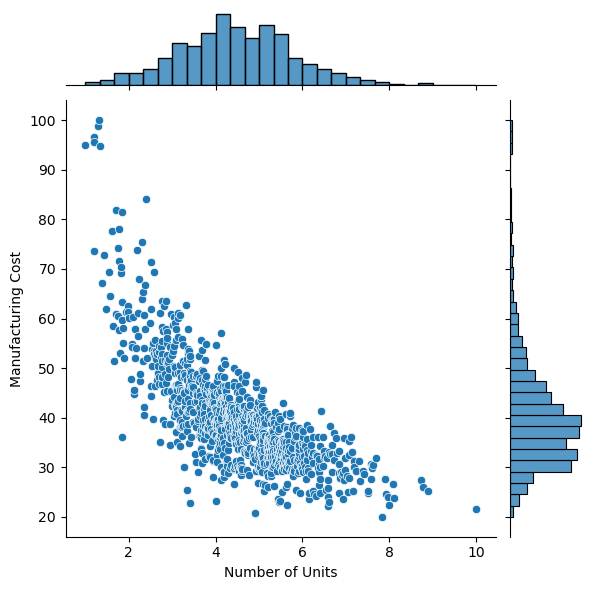

In [9]:
sns.jointplot(data=manufacturing, x='Number of Units', y='Manufacturing Cost')
plt.show()

### Data Spliting & Preprocessing

In [10]:
X = manufacturing[['Number of Units']]
y = manufacturing[['Manufacturing Cost']]

### Model Training & Building

#### 1] Linear Model

In [11]:
from sklearn.linear_model import LinearRegression

In [12]:
reg = LinearRegression(fit_intercept=True)

In [13]:
reg.fit(X,y)

LinearRegression()

In [14]:
reg.coef_

array([[-6.0333683]])

In [15]:
reg.intercept_

array([67.03904193])

### Visualizing Result

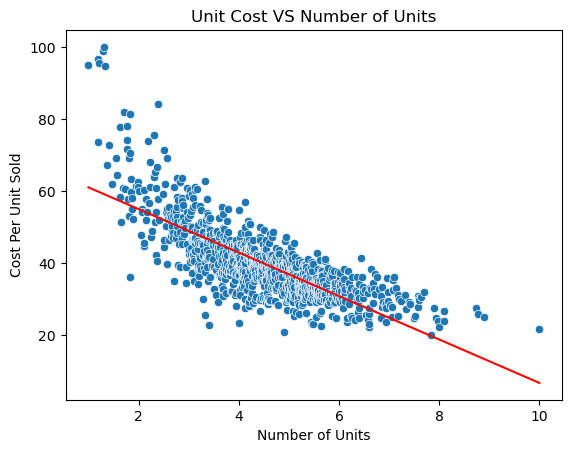

In [18]:
sns.scatterplot(data=manufacturing, x='Number of Units', y='Manufacturing Cost')
plt.plot(X, reg.predict(X), c='r')
plt.title('Unit Cost VS Number of Units')
plt.ylabel('Cost Per Unit Sold')
plt.show()

## The Linear Regression model did not fit the data well, so I will switch to a Polynomial Regression model for a better fit.

#### 2] Polynomial Model

In [19]:
from sklearn.preprocessing import PolynomialFeatures

In [59]:
poly = PolynomialFeatures(degree=4)

In [60]:
X_poly = poly.fit_transform(X)

In [61]:
reg_poly = LinearRegression()

In [62]:
reg_poly.fit(X_poly, y)

LinearRegression()

In [63]:
reg_poly.coef_

array([[ 0.00000000e+00, -5.43308190e+01,  1.22452385e+01,
        -1.29910949e+00,  5.12914120e-02]])

In [64]:
reg_poly.intercept_

array([131.71715954])

### Visualizing Result

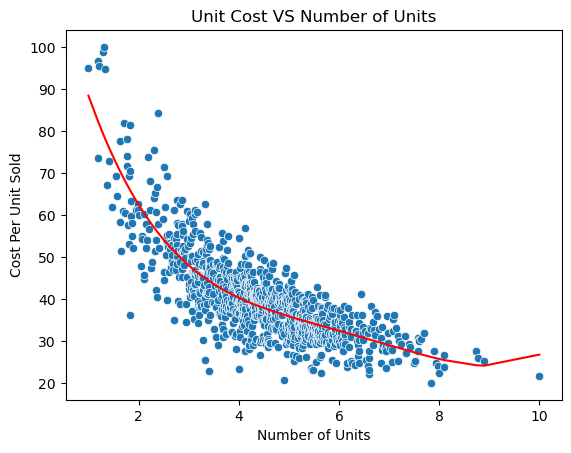

In [65]:
sns.scatterplot(data=manufacturing, x='Number of Units', y='Manufacturing Cost')
plt.plot(X, reg_poly.predict(X_poly), c='r')
plt.title('Unit Cost VS Number of Units')
plt.ylabel('Cost Per Unit Sold')
plt.show()

### Model Evaluation

In [66]:
reg.score(X,y)

0.5789767558506287

In [67]:
reg_poly.score(X_poly,y)

0.6931523968815348